In [1]:
import arviz as az
import bambi as bmb
import numpy as np
import polars as pl

from matplotlib import pyplot as plt

In [2]:
msts = pl.read_csv("../data/prepared/blood_glucose.csv")
msts

value,rat,stage,age,gtyp,sex,too_high,log_value
f64,str,str,str,str,str,str,f64
31.6,"""20240814a""","""beforeAnesthesia""","""Young""","""fa/fa""","""M""","""none""",3.453157
30.2,"""20240814a""","""vehicle""","""Young""","""fa/fa""","""M""","""none""",3.407842
25.0,"""20240814a""","""empa""","""Young""","""fa/fa""","""M""","""none""",3.218876
7.7,"""20240815a""","""beforeAnesthesia""","""Young""","""fa/+""","""F""","""none""",2.04122
18.4,"""20240815a""","""vehicle""","""Young""","""fa/+""","""F""","""none""",2.912351
…,…,…,…,…,…,…,…
30.9,"""20241030a""","""vehicle""","""Adult""","""fa/fa""","""F""","""none""",3.430756
27.866667,"""20241030a""","""empa""","""Adult""","""fa/fa""","""F""","""none""",3.327431
33.7,"""20241030b""","""beforeAnesthesia""","""Adult""","""fa/fa""","""F""","""right""",3.517498


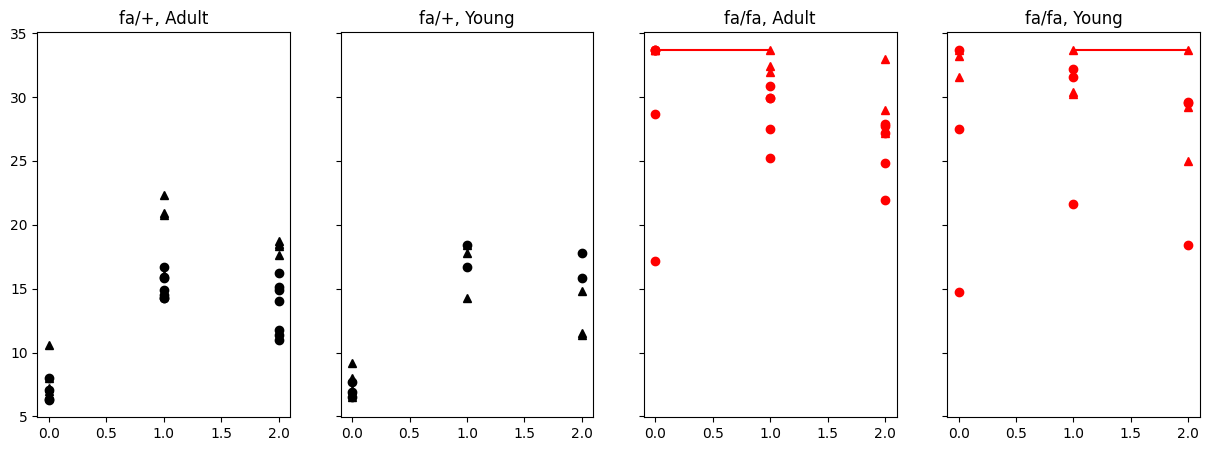

In [3]:
f, axes = plt.subplots(1, 4, sharey=True, figsize=[15, 5])
for ax, ((gtyp, age), subdf) in zip(
    axes, 
    msts.sort("gtyp", "age").group_by("gtyp", "age", maintain_order=True)
):
    for row in subdf.pivot(on="stage", values="value").rows(named=True):
        marker = "^" if row["sex"] == "M" else "o"
        color = "black" if row["gtyp"] == "fa/+" else "red"
        ax.plot(
            [row["beforeAnesthesia"], row["vehicle"], row["empa"]],
            marker=marker, 
            color=color
        )
        ax.set_title(f"{gtyp}, {age}")
    

In [4]:
idata = az.from_netcdf("../results/idata_blood_glucose.nc")

In [5]:
# all_msts = (
#     pl.DataFrame({"rat": msts["rat"].unique(), "beforeAnesthesia": 1, "vehicle": 2, "empa": 3})
#     .unpivot(index="rat", variable_name="stage", value_name="order")
#     .sort("rat", "order")
#     .join(msts[["rat", "age", "gtyp", "sex"]].unique(), on="rat", how="left")
#     .drop("order")
# )
# all_msts

In [6]:
# formula = "censored(log_value, too_high) ~ (0 + gtyp|rat) + stage + gtyp + sex + stage:gtyp + stage:sex"

# filter_missing_measurements = ~(
#     pl.col("value").is_null() & 
#     ((pl.col("gtyp") == "fa/+") | (pl.col("rat") == "20240816a"))
# )
# model_df = (
#     msts[["rat", "stage", "value"]]
#     .join(all_msts, on=("rat", "stage"), how="right")
#     .filter(filter_missing_measurements)
#     .with_columns(
#         too_high=pl.when(pl.col("value").is_null()).then(pl.lit("right")).otherwise(pl.lit("none")),
#         value=pl.when(pl.col("value").is_null()).then(TOP_VALUE).otherwise(pl.col("value")),
#     )
#     .with_columns(log_value=np.log(pl.col("value")))
# )
# model_df
# priors = {
#     "gtyp|rat": bmb.Prior("Normal", mu=0.0, sigma=bmb.Prior("HalfNormal", sigma=[1.0, 1.0])),
#     "stage": bmb.Prior("Normal", mu=0.0, sigma=1.0),
#     "stage:gtyp": bmb.Prior("Normal", mu=0.0, sigma=1.0),
#     "stage:sex": bmb.Prior("Normal", mu=0.0, sigma=1.0),
#     "gtyp": bmb.Prior("Normal", mu=0.0, sigma=1.0),
#     "sex": bmb.Prior("Normal", mu=0.0, sigma=1.0),

    
# }

# model = bmb.Model(formula=formula, data=model_df.to_pandas(), priors=priors)
# model

In [7]:
# msts.max()

In [8]:
# idata = model.fit(idata_kwargs={"log_likelihood": True})

In [9]:
az.summary(idata, var_names=["~gtyp|rat", "~exp_mu", "~mu"])

/Users/tedgro/repos/teddygroves/kidney/.venv/lib/python3.13/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['exp_mu'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.146,0.016,0.118,0.177,0.000,0.000,1969.0,2680.0,1.0
Intercept,1.893,0.057,1.781,1.999,0.001,0.001,2208.0,2564.0,1.0
stage[empa],0.747,0.068,0.620,0.874,0.001,0.001,2661.0,2845.0,1.0
stage[vehicle],0.864,0.067,0.735,0.986,0.001,0.001,2129.0,2807.0,1.0
gtyp[fa/fa],1.487,0.078,1.333,1.629,0.002,0.001,1863.0,2648.0,1.0
sex[M],0.175,0.070,0.043,0.302,0.001,0.001,2627.0,2744.0,1.0
"stage:gtyp[empa, fa/fa]",-0.865,0.082,-1.021,-0.707,0.001,0.001,3105.0,2914.0,1.0
"stage:gtyp[vehicle, fa/fa]",-0.888,0.083,-1.040,-0.730,0.001,0.001,3155.0,2702.0,1.0
"stage:sex[empa, M]",-0.060,0.080,-0.208,0.089,0.001,0.001,3040.0,2778.0,1.0
"stage:sex[vehicle, M]",-0.014,0.082,-0.169,0.138,0.001,0.001,3126.0,3153.0,1.0


In [10]:
# idata = model.predict(idata, data=model_df, inplace=False, kind="response_params")
# idata = model.predict(idata, data=model_df, inplace=False, kind="response")
idata.posterior["exp_mu"] = np.exp(idata.posterior["mu"])

[Text(0.5, 0, 'ln(model prediction)'), Text(0, 0.5, 'ln(measurement)')]

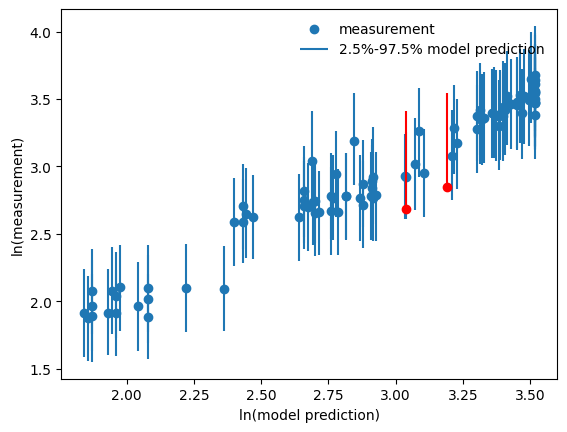

In [11]:
msts=msts.with_columns(
    low=idata.posterior_predictive["censored(log_value, too_high)"].quantile(0.025, dim=["chain", "draw"]).to_numpy(),
    med=idata.posterior_predictive["censored(log_value, too_high)"].quantile(0.5, dim=["chain", "draw"]).to_numpy(),
    high=idata.posterior_predictive["censored(log_value, too_high)"].quantile(0.975, dim=["chain", "draw"]).to_numpy(),
)
bad_prediction = (pl.col("log_value") > pl.col("high")) | (pl.col("log_value") < pl.col("low"))

f, ax = plt.subplots()
ax.scatter(msts["log_value"], msts["med"], label="measurement")
ax.vlines(msts["log_value"], msts["low"], msts["high"], zorder=-1, label="2.5%-97.5% model prediction")

bad = msts.filter(bad_prediction)
ax.scatter(bad["med"], bad["log_value"], color="red")
ax.vlines(bad["med"], bad["low"], bad["high"], color="red")

ax.legend(frameon=False);
ax.set(xlabel="ln(model prediction)", ylabel="ln(measurement)")

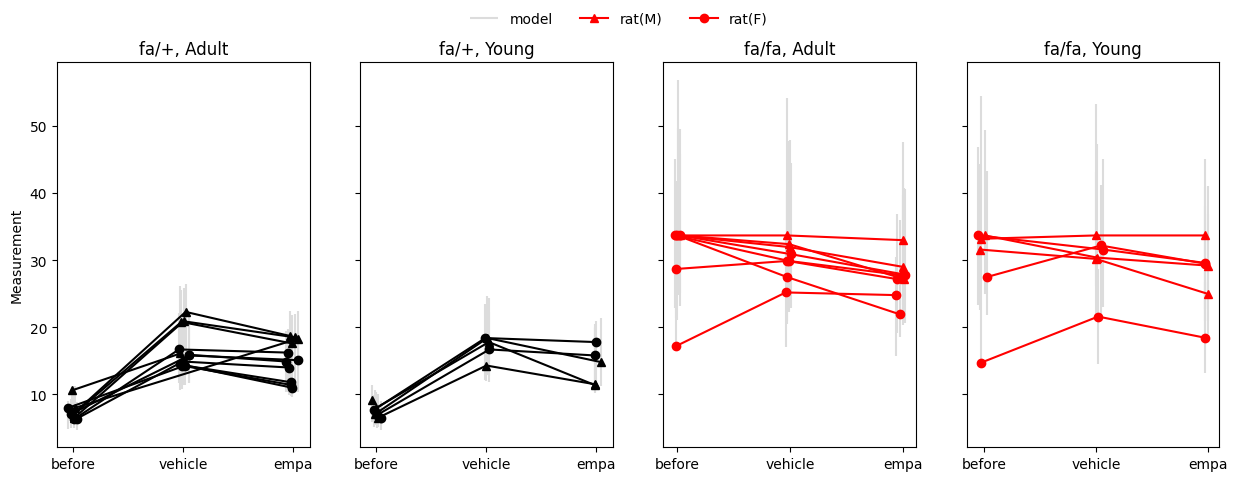

In [12]:
top_value = msts["value"].max() + 0.5
stage_order = {"beforeAnesthesia": 0, "vehicle": 1, "empa": 2}
f, axes = plt.subplots(1, 4, sharey=True, figsize=[15, 5])
plot_lines = {}
for ax, ((gtyp, age), subdf) in zip(
    axes, 
    msts.with_columns(stage_order=pl.col("stage").replace(stage_order)).sort("gtyp", "age", "stage_order").group_by("gtyp", "age", maintain_order=True)
):
    for (rat,), subsubdf in subdf.sort("stage_order").group_by("rat"):
        jitter = np.random.normal(size=len(subsubdf), scale=0.03)
        marker = "^" if subsubdf["sex"][0] == "M" else "o"
        color = "black" if subsubdf["gtyp"][0] == "fa/+" else "red"
        x = [stage_order[stage] for stage in subsubdf["stage"]]
        plot_lines[subsubdf["sex"][0]] = ax.plot(x + jitter, subsubdf["value"].replace(top_value, np.nan), marker=marker, color=color)
        vlines = ax.vlines(x + jitter, np.exp(subsubdf["low"]), np.exp(subsubdf["high"]), color="gainsboro", zorder=-1)
    ax.set_title(f"{gtyp}, {age}")
    ax.set_xticks([0, 1, 2], ["before", "vehicle", "empa"])
axes[0].set_ylabel("Measurement");
f.legend([vlines, plot_lines["M"][0], plot_lines["F"][0]], ["model", "rat(M)", "rat(F)"], frameon=False, ncol=3, loc="upper center");